In [2]:
from typing import Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [3]:

load_dotenv()

True

In [16]:

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    temperature=0.7
)

In [5]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [17]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}

In [18]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

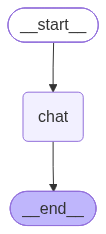

In [9]:
app

In [32]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '12345'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [33]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='b12cf298-d8db-4e38-80d1-cae872465d84')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='9636c61e1855127d3fe6f09ed334a692')]}

In [34]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [35]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [ ]:
# Resume the graph with the rejected decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [38]:
print(final_result['messages'][-1].content)

Not approved.


In [ ]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [31]:
print(final_result['messages'][-1].content[0]["text"])

Imagine you are **blindfolded on top of a foggy mountain**, and your goal is to reach the very bottom (the valley). 

Because you can’t see, you have to use your feet to feel the slope of the ground. 

Here is how you would get to the bottom:
1. **Feel the slope:** You feel the ground with your feet to see which direction slopes downward.
2. **Take a step:** You take a step in that downward direction.
3. **Repeat:** You feel the slope again, take another step, and repeat this process over and over until the ground feels completely flat. You have arrived at the bottom!

This is exactly how **Gradient Descent** works for computers.

---

### How it applies to Computers (Machine Learning)

In machine learning, the computer is trying to solve a puzzle (like predicting house prices or recognizing cats). 

* **The Mountain** represents the computer’s **errors**. 
  * Being high up on the mountain means making huge mistakes.
  * Being at the bottom of the valley means making almost zero mista